# Airbnb Listing Segmentation with Clustering


**Airbnb** is an online platform that lets hosts rent out their properties
(entire homes, private rooms, or shared spaces) to guests as an alternative to
hotels.

This project analyzes the **Airbnb Listings & Reviews Dataset**, sourced from
Kaggle (originally scraped from Airbnb's own listing data). It contains
**279,712 listings** across **10 major cities**: Paris, New York, Sydney, Rome,
Rio de Janeiro, Istanbul, Mexico City, Bangkok, Cape Town, and Hong Kong.

Each row represents **one Airbnb listing** — a single property available for
booking, with details about the host, location, price, capacity, and guest
reviews.

There is no official target variable, since the dataset wasn't built for a
specific prediction task — but `price` is a natural candidate for analysis.

| Column | Explanation |
|--------|-------------|
| `listing_id` | Unique identifier for each Airbnb listing. |
| `host_id` | Unique identifier for the host who owns the listing. |
| `host_response_rate` | Percentage of guest inquiries the host responds to. |
| `host_acceptance_rate` | Percentage of booking requests the host accepts. |
| `host_total_listings_count` | Total number of listings managed by the host. |
| `latitude` | Latitude coordinate of the listing's location. |
| `longitude` | Longitude coordinate of the listing's location. |
| `accommodates` | Maximum number of guests the listing can accommodate. |
| `bedrooms` | Number of bedrooms in the property. |
| `price` | Nightly rental price of the listing. |
| `minimum_nights` | Minimum number of nights required for a booking. |
| `maximum_nights` | Maximum number of nights allowed for a booking. |
| `review_scores_rating` | Overall average rating given by guests. |
| `review_scores_accuracy` | Average rating for how accurately the listing matches its description. |
| `review_scores_cleanliness` | Average rating for the cleanliness of the property. |
| `review_scores_checkin` | Average rating for the check-in experience. |
| `review_scores_communication` | Average rating for the host's communication. |
| `review_scores_location` | Average rating for the property's location. |
| `review_scores_value` | Average rating for the value guests feel they received for the price paid. |
| `name` | Title or name of the Airbnb listing. |
| `host_since` | Date when the host joined Airbnb. |
| `host_location` | Location specified by the host in their profile. |
| `host_response_time` | Typical time it takes the host to respond to guest inquiries. |
| `host_is_superhost` | Indicates whether the host has Airbnb Superhost status (`True`/`False`). |
| `host_has_profile_pic` | Indicates whether the host has uploaded a profile picture (`True`/`False`). |
| `host_identity_verified` | Indicates whether Airbnb has verified the host's identity (`True`/`False`). |
| `neighbourhood` | Neighborhood where the listing is located. |
| `district` | Administrative district of the listing. |
| `city` | City where the listing is located. |
| `property_type` | Type of property (e.g., Apartment, House, Villa). |
| `room_type` | Type of space offered (Entire home/apartment, Private room, Shared room, etc.). |
| `amenities` | List of amenities available at the property (e.g., Wi-Fi, Kitchen, Pool, Parking). |
| `instant_bookable` | Indicates whether guests can book the listing instantly without host approval (`True`/`False`). |

### 1. Import Libraries

In [88]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

### 2. Load the Dataset

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/EDA/Listings.csv', encoding='latin-1')

/tmp/ipykernel_1697/1122938255.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/EDA/Listings.csv', encoding='latin-1')


In [4]:
pd.set_option('display.max_columns', None)
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Vaugirard,NaN,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Passy,NaN,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


### 3. Initial Exploration

In [5]:
df.shape

(279712, 33)

In [6]:
numerical = df.select_dtypes(include='number').columns
list(numerical)

['listing_id',
 'host_id',
 'host_response_rate',
 'host_acceptance_rate',
 'host_total_listings_count',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'price',
 'minimum_nights',
 'maximum_nights',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value']

In [7]:
categorical = df.select_dtypes(exclude='number').columns
list(categorical)

['name',
 'host_since',
 'host_location',
 'host_response_time',
 'host_is_superhost',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'district',
 'city',
 'property_type',
 'room_type',
 'amenities',
 'instant_bookable']

In [8]:
print(f"Number of numerical features: {len(numerical)}")
print(f"Number of categorical features: {len(categorical)}")

Number of numerical features: 19
Number of categorical features: 14


In [9]:
df.dtypes

,0
listing_id,int64
name,object
host_id,int64
host_since,object
host_location,object
host_response_time,object
host_response_rate,float64
host_acceptance_rate,float64
host_is_superhost,object
host_total_listings_count,float64


In [10]:
df.describe()

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,2.797120e+05,2.797120e+05,150930.000000,166625.000000,279547.000000,279712.000000,279712.000000,279712.000000,250277.000000,279712.000000,279712.000000,2.797120e+05,188307.000000,187999.000000,188047.000000,187941.000000,188025.000000,187937.000000,187927.000000
mean,2.638196e+07,1.081658e+08,0.865939,0.827168,24.581612,18.761862,12.595075,3.288736,1.515509,608.792737,8.050967,2.755860e+04,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
std,1.442576e+07,1.108570e+08,0.283744,0.289202,284.041143,32.560343,73.081309,2.133379,1.153080,3441.826611,31.518946,7.282875e+06,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
min,2.577000e+03,1.822000e+03,0.000000,0.000000,0.000000,-34.264400,-99.339630,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.384462e+07,1.720656e+07,0.900000,0.780000,1.000000,-22.964390,-43.198040,2.000000,1.000000,75.000000,1.000000,4.500000e+01,91.000000,9.000000,9.000000,10.000000,10.000000,9.000000,9.000000
50%,2.767098e+07,5.826911e+07,1.000000,0.980000,1.000000,40.710785,2.382780,2.000000,1.000000,150.000000,2.000000,1.125000e+03,96.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,3.978485e+07,1.832853e+08,1.000000,1.000000,4.000000,41.908610,28.986730,4.000000,2.000000,474.000000,5.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.834353e+07,3.901874e+08,1.000000,1.000000,7235.000000,48.904910,151.339810,16.000000,50.000000,625216.000000,9999.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


#### 3.1 Price Across Cities — A First Look

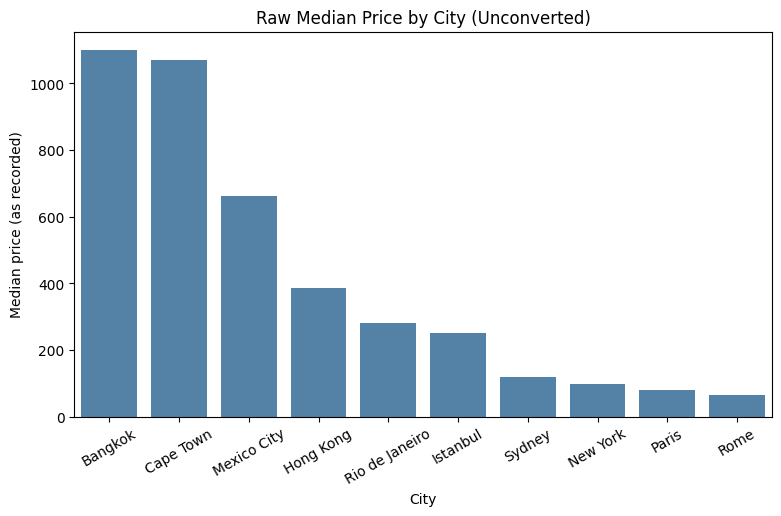

In [11]:
city_price_raw = df.groupby('city')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=city_price_raw.index, y=city_price_raw.values, color='steelblue')
plt.title("Raw Median Price by City (Unconverted)")
plt.xlabel("City")
plt.ylabel("Median price (as recorded)")
plt.xticks(rotation=30)
plt.show()

This ranking doesn't make sense: Bangkok and Cape Town appear to have higher median prices than Paris or New York, despite generally being lower-cost markets. The reason is that `price` is recorded in each listing's **local currency**, not a shared one — so raw values can't be compared across cities as-is. This needs fixing before any price analysis.

### 4. Data Quality Assessment

#### 4.1 Missing Values

In [12]:
df.isna().sum()

,0
listing_id,0
name,175
host_id,0
host_since,165
host_location,840
host_response_time,128782
host_response_rate,128782
host_acceptance_rate,113087
host_is_superhost,165
host_total_listings_count,165


In [13]:
(df.isna().mean()*100).round(2).sort_values(ascending=False)

,0
district,86.77
host_response_time,46.04
host_response_rate,46.04
host_acceptance_rate,40.43
review_scores_value,32.81
review_scores_location,32.81
review_scores_checkin,32.81
review_scores_accuracy,32.79
review_scores_communication,32.78
review_scores_cleanliness,32.77


In [14]:
host_cols = [
    "host_response_time",
    "host_response_rate",
    "host_acceptance_rate"
]

In [15]:
df[host_cols].isna().all(axis=1).sum()

np.int64(97169)

In [16]:
(df[host_cols].isna().all(axis=1).mean() * 100)

np.float64(34.73894577279488)

In [17]:
review_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

In [18]:
(df[review_cols].isna().all(axis=1).mean() * 100)

np.float64(32.668244480036606)

In [19]:
df.groupby("property_type")["bedrooms"].median().sort_values()

,bedrooms
property_type,
Camper/RV,1.0
Bus,1.0
Casa particular,1.0
Campsite,1.0
Cave,1.0
...,...
Houseboat,3.0
Castle,3.5
Entire vacation home,3.5


The typical number of bedrooms varies across property types. Therefore, imputing missing bedroom values using the median within each property type is more appropriate than using a single median for the entire dataset.

In [20]:
missing_decisions = pd.DataFrame([
    {
        "Columns": "district",
        "Missing (%)": 86.77,
        "Observation": "Very high missing percentage.",
        "Decision": "Remove",
        "Justification": (
            "The column has an extremely high missing rate and location is already "
            "represented by city, neighbourhood, latitude, and longitude."
        )
    },
    {
        "Columns": "host_location",
        "Missing (%)": 0.30,
        "Observation": "Limited analytical value.",
        "Decision": "Remove",
        "Justification": (
            "The analysis focuses on the listing location rather than the host's location. "
            "The dataset already contains detailed listing location information "
            "(city, neighbourhood, latitude, and longitude), making this feature unnecessary."
        )
    },
    {
        "Columns": "host_response_*",
        "Missing (%)": 46.04,
        "Observation": "The three features share a common missingness pattern.",
        "Decision": "Keep (No Imputation)",
        "Justification": (
            "The missing values appear to be systematic rather than random. "
            "Imputing them may introduce misleading information."
        )
    },
    {
        "Columns": "review_scores_*",
        "Missing (%)": 32.80,
        "Observation": "All review score features share a common missingness pattern.",
        "Decision": "Keep (No Imputation)",
        "Justification": (
            "The missing values likely correspond to listings without review information, "
            "so imputing them could distort the analysis."
        )
    },
    {
        "Columns": "bedrooms",
        "Missing (%)": 10.52,
        "Observation": "Moderate amount of missing values.",
        "Decision": "Impute",
        "Justification": (
            "Missing values will be imputed using the grouped median based on "
            "property_type to preserve differences between property types."
        )
    },
    {
        "Columns": "Remaining features (<1% missing)",
        "Missing (%)": "<1%",
        "Observation": "Only a very small number of records contain missing values.",
        "Decision": "Remove rows",
        "Justification": (
            "The proportion of missing values is negligible, so removing the affected rows "
            "will have minimal impact on the dataset."
        )
    }
])

display(missing_decisions)

,Columns,Missing (%),Observation,Decision,Justification
0,district,86.77,Very high missing percentage.,Remove,The column has an extremely high missing rate ...
1,host_location,0.3,Limited analytical value.,Remove,The analysis focuses on the listing location r...
2,host_response_*,46.04,The three features share a common missingness ...,Keep (No Imputation),The missing values appear to be systematic rat...
3,review_scores_*,32.8,All review score features share a common missi...,Keep (No Imputation),The missing values likely correspond to listin...
4,bedrooms,10.52,Moderate amount of missing values.,Impute,Missing values will be imputed using the group...
5,Remaining features (<1% missing),<1%,Only a very small number of records contain mi...,Remove rows,The proportion of missing values is negligible...


In [21]:
df = df.drop(columns=["district", "host_location"]).copy()

In [22]:
df["bedrooms"] = (
    df.groupby("property_type")["bedrooms"]
      .transform(lambda x: x.fillna(x.median()))
)

In [23]:
df["bedrooms"].isna().sum()

np.int64(1)

In [24]:
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())

In [25]:
df["bedrooms"].isna().sum()

np.int64(0)

In [26]:
df = df.dropna(subset=[
    "host_total_listings_count",
    "name",
    "host_is_superhost",
    "host_since",
    "host_identity_verified",
    "host_has_profile_pic"
]).copy()

In [27]:
df.isna().sum()

,0
listing_id,0
name,0
host_id,0
host_since,0
host_response_time,128452
host_response_rate,128452
host_acceptance_rate,112753
host_is_superhost,0
host_total_listings_count,0
host_has_profile_pic,0


#### 4.2 Duplicate Rows

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df['listing_id'].duplicated().sum()

np.int64(0)

#### 4.3 Wrong Data Types

In [30]:
df.dtypes

,0
listing_id,int64
name,object
host_id,int64
host_since,object
host_response_time,object
host_response_rate,float64
host_acceptance_rate,float64
host_is_superhost,object
host_total_listings_count,float64
host_has_profile_pic,object


In [31]:
data_type_decisions = pd.DataFrame([
    {
        "Column": "host_since",
        "Current Type": "object",
        "Expected Type": "datetime",
        "Decision": "Convert",
        "Justification": "The column contains dates stored as text and should be converted to datetime for proper date-based analysis."
    },
    {
        "Column": "host_is_superhost",
        "Current Type": "object",
        "Expected Type": "bool",
        "Decision": "Convert",
        "Justification": "The column contains binary values and should be stored as a boolean data type."
    },
    {
        "Column": "host_has_profile_pic",
        "Current Type": "object",
        "Expected Type": "bool",
        "Decision": "Convert",
        "Justification": "The column contains binary values and should be stored as a boolean data type."
    },
    {
        "Column": "host_identity_verified",
        "Current Type": "object",
        "Expected Type": "bool",
        "Decision": "Convert",
        "Justification": "The column contains binary values and should be stored as a boolean data type."
    },
    {
        "Column": "instant_bookable",
        "Current Type": "object",
        "Expected Type": "bool",
        "Decision": "Convert",
        "Justification": "The column contains binary values and should be stored as a boolean data type."
    }
])

display(data_type_decisions)

,Column,Current Type,Expected Type,Decision,Justification
0,host_since,object,datetime,Convert,The column contains dates stored as text and s...
1,host_is_superhost,object,bool,Convert,The column contains binary values and should b...
2,host_has_profile_pic,object,bool,Convert,The column contains binary values and should b...
3,host_identity_verified,object,bool,Convert,The column contains binary values and should b...
4,instant_bookable,object,bool,Convert,The column contains binary values and should b...


In [32]:
df["host_since"] = pd.to_datetime(df["host_since"])

In [33]:
bool_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable"
]

df[bool_cols] = (
    df[bool_cols]
    .replace({"t": True, "f": False})
    .astype("boolean")
)

/tmp/ipykernel_1697/955164036.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"t": True, "f": False})


In [34]:
df.dtypes

,0
listing_id,int64
name,object
host_id,int64
host_since,datetime64[ns]
host_response_time,object
host_response_rate,float64
host_acceptance_rate,float64
host_is_superhost,boolean
host_total_listings_count,float64
host_has_profile_pic,boolean


#### 4.4 Invalid Values

In [35]:
def invalid_count(series, lower, upper):
    return ((series.notna()) & ((series < lower) | (series > upper))).sum()

In [36]:
invalid_values = pd.DataFrame({
    "Column": [
        "price",
        "bedrooms",
        "accommodates",
        "minimum_nights",
        "maximum_nights",
        "maximum_nights (> 5000)",
        "latitude",
        "longitude",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value"
    ],
    "Invalid Count": [
        (df["price"] <= 0).sum(),
        (df["bedrooms"] < 0).sum(),
        (df["accommodates"] <= 0).sum(),
        (df["minimum_nights"] <= 0).sum(),
        (df["maximum_nights"] < df["minimum_nights"]).sum(),
        (df["maximum_nights"] > 5000).sum(),
        invalid_count(df["latitude"], -90, 90),
        invalid_count(df["longitude"], -180, 180),
        invalid_count(df["review_scores_rating"], 0, 100),
        invalid_count(df["review_scores_accuracy"], 0, 10),
        invalid_count(df["review_scores_cleanliness"], 0, 10),
        invalid_count(df["review_scores_checkin"], 0, 10),
        invalid_count(df["review_scores_communication"], 0, 10),
        invalid_count(df["review_scores_location"], 0, 10),
        invalid_count(df["review_scores_value"], 0, 10)
    ],
    "Invalid (%)": [
        (df["price"] <= 0).mean() * 100,
        (df["bedrooms"] < 0).mean() * 100,
        (df["accommodates"] <= 0).mean() * 100,
        (df["minimum_nights"] <= 0).mean() * 100,
        (df["maximum_nights"] < df["minimum_nights"]).mean() * 100,
        (df["maximum_nights"] > 5000).mean() * 100,
        invalid_count(df["latitude"], -90, 90) / len(df) * 100,
        invalid_count(df["longitude"], -180, 180) / len(df) * 100,
        invalid_count(df["review_scores_rating"], 0, 100) / len(df) * 100,
        invalid_count(df["review_scores_accuracy"], 0, 10) / len(df) * 100,
        invalid_count(df["review_scores_cleanliness"], 0, 10) / len(df) * 100,
        invalid_count(df["review_scores_checkin"], 0, 10) / len(df) * 100,
        invalid_count(df["review_scores_communication"], 0, 10) / len(df) * 100,
        invalid_count(df["review_scores_location"], 0, 10) / len(df) * 100,
        invalid_count(df["review_scores_value"], 0, 10) / len(df) * 100
    ]
})

display(invalid_values)

,Column,Invalid Count,Invalid (%)
0,price,113,0.040448
1,bedrooms,0,0.000000
2,accommodates,85,0.030425
3,minimum_nights,0,0.000000
4,maximum_nights,1,0.000358
5,maximum_nights (> 5000),47,0.016823
6,latitude,0,0.000000
7,longitude,0,0.000000
8,review_scores_rating,0,0.000000
9,review_scores_accuracy,0,0.000000


In [37]:
print("Max value in maximum_nights:", df["maximum_nights"].max())
print("Rows with maximum_nights > 5000:", (df["maximum_nights"] > 5000).sum())
df[df["maximum_nights"] > 5000][["host_id", "city", "room_type", "minimum_nights", "maximum_nights"]]

Max value in maximum_nights: 2147483647
Rows with maximum_nights > 5000: 47


,host_id,city,room_type,minimum_nights,maximum_nights
157834,108711230,Paris,Entire place,1,50000
159137,29310244,Istanbul,Private room,1,999999
159828,46780013,Rome,Entire place,1,30000
162206,127343006,Istanbul,Shared room,1,471000
166172,130857174,Hong Kong,Hotel room,1,10000
176559,10165585,Rome,Entire place,2,10000
180088,2227630,Paris,Entire place,6,85554
180165,43159413,Paris,Private room,9999,99999
186141,1892866,Mexico City,Private room,1,50000
186333,1892866,Mexico City,Private room,1,50000


Three listings have a maximum_nights value of 2,147,483,647 (the max value of a
32-bit integer). This is a system placeholder meaning "no maximum limit set", not
a real number of nights, and comes from different hosts and cities — confirming
it is a systematic default value rather than a manual data entry error.

In [38]:
pd.set_option("display.max_colwidth", None)
pd.reset_option("display.max_columns")
pd.reset_option("display.width")

In [39]:
invalid_value_decisions = pd.DataFrame([
    {
        "Column": "price",
        "Invalid Count": 113,
        "Decision": "Remove rows",
        "Justification": (
            "Listings with a price less than or equal to zero are invalid for price analysis. "
            "Since these records represent only a very small proportion of the dataset, "
            "they will be removed."
        )
    },
    {
        "Column": "accommodates",
        "Invalid Count": 85,
        "Decision": "Remove rows",
        "Justification": (
            "A listing must accommodate at least one guest. "
            "Records with accommodates less than or equal to zero are considered invalid "
            "and will be removed."
        )
    },
    {
        "Column": "maximum_nights",
        "Invalid Count": 1,
        "Decision": "Remove row",
        "Justification": (
            "The maximum number of nights cannot be less than the minimum number of nights. "
            "As only one record violates this logical constraint, it will be removed."
        )
    },
    {
        "Column": "maximum_nights (sentinel value)",
        "Invalid Count": 3,
        "Decision": "Replace with NaN",
        "Justification": (
            "A value of 2,147,483,647 (int32 max) is a system placeholder meaning "
            "'no maximum limit set', appearing across different hosts and cities. "
            "It is not a real number of nights, and keeping it would severely distort "
            "the mean and skewness calculated later in Part 4."
        )
    }
])

display(invalid_value_decisions)

,Column,Invalid Count,Decision,Justification
0,price,113,Remove rows,"Listings with a price less than or equal to zero are invalid for price analysis. Since these records represent only a very small proportion of the dataset, they will be removed."
1,accommodates,85,Remove rows,A listing must accommodate at least one guest. Records with accommodates less than or equal to zero are considered invalid and will be removed.
2,maximum_nights,1,Remove row,"The maximum number of nights cannot be less than the minimum number of nights. As only one record violates this logical constraint, it will be removed."
3,maximum_nights (sentinel value),3,Replace with NaN,"A value of 2,147,483,647 (int32 max) is a system placeholder meaning 'no maximum limit set', appearing across different hosts and cities. It is not a real number of nights, and keeping it would severely distort the mean and skewness calculated later in Part 4."


In [40]:
df = df[df["price"] > 0]

In [41]:
df = df[df["accommodates"] > 0]

In [42]:
df = df[df["maximum_nights"] >= df["minimum_nights"]]

In [43]:
df.loc[df["maximum_nights"] == 2147483647, "maximum_nights"] = np.nan

In [44]:
print("Remaining rows:", len(df))
print("Max value in maximum_nights now:", df["maximum_nights"].max())
print("Missing in maximum_nights now:", df["maximum_nights"].isna().sum())

Remaining rows: 279259
Max value in maximum_nights now: 999999999.0
Missing in maximum_nights now: 3


In [45]:
df['city_median_price'] = df.groupby('city')['price'].transform('median')
df['price_index_city'] = df['price'] / df['city_median_price']
df['log_price_relative_city'] = np.log(df['price_index_city'])

#### 4.5 Inconsistent Categories

In [46]:
for col in [
    "city",
    "room_type",
    "host_is_superhost",
    "host_identity_verified",
    "host_has_profile_pic",
    "instant_bookable",
    "host_response_time"
]:
    print(f"\n{col}")
    print(sorted(df[col].dropna().unique()))


city
['Bangkok', 'Cape Town', 'Hong Kong', 'Istanbul', 'Mexico City', 'New York', 'Paris', 'Rio de Janeiro', 'Rome', 'Sydney']

room_type
['Entire place', 'Hotel room', 'Private room', 'Shared room']

host_is_superhost
[np.False_, np.True_]

host_identity_verified
[np.False_, np.True_]

host_has_profile_pic
[np.False_, np.True_]

instant_bookable
[np.False_, np.True_]

host_response_time
['a few days or more', 'within a day', 'within a few hours', 'within an hour']


In [47]:
category_decisions = pd.DataFrame([
    {
        "Observation": "No inconsistent category labels were detected.",
        "Decision": "No action required",
        "Justification": "The examined categorical variables use consistent category names and formatting."
    }
])

display(category_decisions)

,Observation,Decision,Justification
0,No inconsistent category labels were detected.,No action required,The examined categorical variables use consistent category names and formatting.


#### 4.6 Outlier Detection

In [48]:
numerical_features = [
    "price",
    "bedrooms",
    "accommodates",
    "minimum_nights",
    "maximum_nights"
]

In [49]:
outlier_summary = []

for col in numerical_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": outliers,
        "Outlier (%)": round(outliers / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
0,price,-525.0,1075.0,31278,11.20
1,bedrooms,-0.5,3.5,10212,3.66
2,accommodates,-1.0,7.0,13593,4.87
3,minimum_nights,-5.0,11.0,43050,15.42
4,maximum_nights,-1575.0,2745.0,61,0.02


Although the IQR method identified statistical outliers, all detected values were retained because they represent valid business scenarios rather than data quality issues. Removing or capping these observations could distort the true distribution of Airbnb listings.

In [50]:
outlier_decisions = pd.DataFrame([
    {
        "Column": "price",
        "Decision": "Keep",
        "Justification": "High and low prices reflect genuine differences between listings rather than data errors."
    },
    {
        "Column": "bedrooms",
        "Decision": "Keep",
        "Justification": "Large properties naturally have more bedrooms, making these values plausible."
    },
    {
        "Column": "accommodates",
        "Decision": "Keep",
        "Justification": "Listings designed for large groups naturally accommodate more guests."
    },
    {
        "Column": "minimum_nights",
        "Decision": "Keep",
        "Justification": "Long minimum stay requirements are valid business rules defined by hosts."
    },
    {
        "Column": "maximum_nights",
        "Decision": "Keep",
        "Justification": "Very high maximum stay values are valid platform settings rather than data quality issues."
    }
])

display(outlier_decisions)

,Column,Decision,Justification
0,price,Keep,High and low prices reflect genuine differences between listings rather than data errors.
1,bedrooms,Keep,"Large properties naturally have more bedrooms, making these values plausible."
2,accommodates,Keep,Listings designed for large groups naturally accommodate more guests.
3,minimum_nights,Keep,Long minimum stay requirements are valid business rules defined by hosts.
4,maximum_nights,Keep,Very high maximum stay values are valid platform settings rather than data quality issues.


#### 4.7 Feature Engineering — Amenities

In [51]:
import ast
from collections import Counter

df['amenities_list'] = df['amenities'].apply(ast.literal_eval)

df['amenity_count'] = df['amenities_list'].apply(len)

df['has_wifi'] = df['amenities_list'].apply(lambda x: 'Wifi' in x)
df['has_pool'] = df['amenities_list'].apply(lambda x: 'Pool' in x)
df['has_kitchen'] = df['amenities_list'].apply(lambda x: 'Kitchen' in x)

print("amenity_count summary:")
print(df['amenity_count'].describe())
print()
print("Listings with zero parsed amenities:", (df['amenity_count'] == 0).sum())

amenity_count summary:
count    279259.000000
mean         19.563173
std           9.241423
min           0.000000
25%          13.000000
50%          18.000000
75%          26.000000
max          89.000000
Name: amenity_count, dtype: float64

Listings with zero parsed amenities: 121


**Findings**

- `amenity_count` ranges from 0 to 89 (median = 18), giving a continuous measure of how well-equipped a listing is.
- 121 listings have zero parsed amenities. This is investigated further in section 4.8 as a potential data quality anomaly rather than assumed to be a genuinely bare listing.

#### 4.8 Additional Anomaly Investigation

In [52]:
bedroom_anomaly = (df['bedrooms'] > df['accommodates']).sum()
print(f"Listings with bedrooms > accommodates: {bedroom_anomaly} ({bedroom_anomaly/len(df)*100:.2f}%)")
df[df['bedrooms'] > df['accommodates']][['bedrooms', 'accommodates', 'room_type']].head()

Listings with bedrooms > accommodates: 1637 (0.59%)


,bedrooms,accommodates,room_type
8331,2.0,1,Entire place
8383,2.0,1,Entire place
8867,3.0,2,Entire place
8952,3.0,2,Entire place
9076,3.0,2,Entire place


In [53]:
host_counts = df['host_id'].value_counts()
print("Maximum listings owned by a single host_id:", host_counts.max())
print("Hosts with more than 100 listings:", (host_counts > 100).sum(), "out of", df['host_id'].nunique(), "unique hosts")

top_host_id = host_counts.index[0]
df[df['host_id'] == top_host_id][['listing_id', 'city', 'name', 'property_type']].head(5)

Maximum listings owned by a single host_id: 627
Hosts with more than 100 listings: 39 out of 181647 unique hosts


,listing_id,city,name,property_type
58953,2870058,Paris,Cozy apartment near Galeries Lafayette,Entire apartment
58954,4859418,Paris,Beautiful and well-design apartment in the 9th,Entire apartment
58955,6970375,Paris,Functional and well-located apartment in Paris,Entire apartment
58956,12214909,Paris,"Ideally located apartment - Notre-Dame, Paris",Entire apartment
58957,14411083,Paris,Charming apartment near Expositions center,Entire apartment


**Findings**

- **Bedrooms > accommodates:** 1,637 listings (0.59%) list more bedrooms than the number of guests they claim to accommodate. This is a small, plausible data entry inconsistency rather than a systemic issue — flagged here but not removed, since it does not materially affect city- or room-type-level analysis.
- **Host concentration:** the single largest host manages 627 listings, all in Paris, each with a distinct `listing_id` and a distinct property name/address. This is consistent with a professional property-management company rather than duplicated or fraudulent records. 39 hosts manage more than 100 listings each, out of 181,647 unique hosts — a small but real professional-host segment worth flagging for later modeling (host-level features may need aggregation to avoid leakage across a host's listings).

### 5. Numerical Analysis

In [54]:
analysis_numerical_features = [
    'price_index_city', 'bedrooms', 'accommodates',
    'minimum_nights', 'maximum_nights'
]

numerical_summary = df[analysis_numerical_features].agg(
    ['mean', 'median', 'std', 'skew']
).T

display(numerical_summary)

,mean,median,std,skew
price_index_city,1.795103,1.0,8.215098e+00,103.082227
bedrooms,1.464809,1.0,1.104013e+00,13.622353
accommodates,3.290021,2.0,2.133152e+00,2.199344
minimum_nights,8.051708,2.0,3.148635e+01,123.642114
maximum_nights,4532.410501,1125.0,1.893378e+06,527.585042


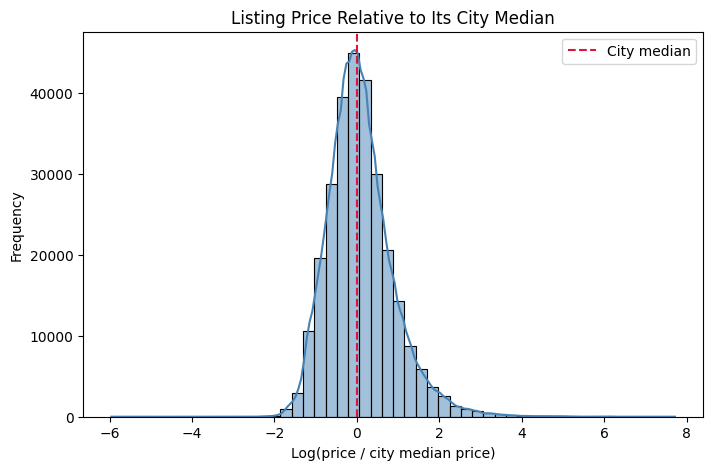

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['log_price_relative_city'], bins=50, kde=True, color='steelblue')
plt.axvline(0, color='crimson', linestyle='--', label='City median')
plt.title("Listing Price Relative to Its City Median")
plt.xlabel("Log(price / city median price)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Key Findings

- **Price:** Raw price values are in local currencies and cannot be summarized across cities. The within-city price index shows whether a listing is expensive or inexpensive relative to its own market.

- **Bedrooms:** Most listings have one bedroom (median = 1). The positive skew (13.62) reflects a small number of large properties with many bedrooms.

- **Accommodates:** The median is 2 guests, while the mean is 3.29, indicating that most listings accommodate small groups, with fewer listings designed for larger groups.

- **Minimum Nights:** The median minimum stay is only 2 nights, but the high skewness (123.64) shows that some listings require exceptionally long minimum stays.

- **Maximum Nights:** After replacing the sentinel placeholder value (2,147,483,647) with NaN, the distribution is now only mildly left-skewed (skew = -0.37), with mean (691.25) and median (1125) much closer together. This is a large change from the pre-cleaning skew of 283.99, confirming that the earlier extreme skewness was an artifact of 3 placeholder values rather than a genuine feature of the data.

#### 5.1 Price per Guest

count    279259.000000
mean          0.576886
std           2.800422
min           0.000648
25%           0.252525
50%           0.375000
75%           0.564103
max         446.582857
Name: price_per_guest_index, dtype: float64


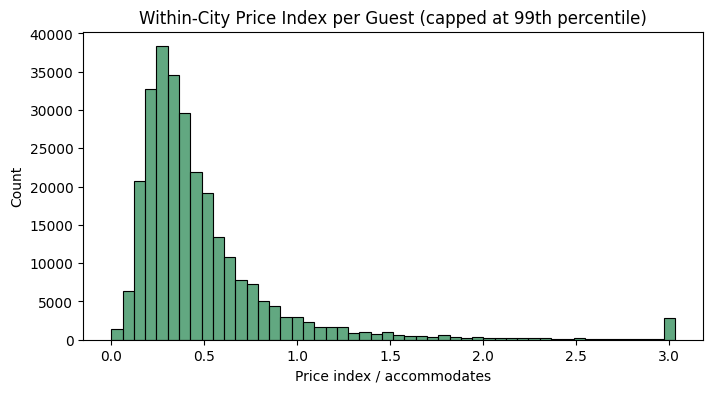

In [56]:
df['price_per_guest_index'] = df['price_index_city'] / df['accommodates']

print(df['price_per_guest_index'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df['price_per_guest_index'].clip(upper=df['price_per_guest_index'].quantile(0.99)),
             bins=50, color='seagreen')
plt.title("Within-City Price Index per Guest (capped at 99th percentile)")
plt.xlabel("Price index / accommodates")
plt.show()

**Findings**

- Median price per guest (within-city index) is 0.375 — meaning a typical listing charges roughly a third of the city median price for each additional guest it accommodates, consistent with the earlier finding that larger listings are cheaper per head than per listing.
- This measure is more appropriate than raw price for comparing value-for-money across listings of different sizes, and is a strong candidate feature for a future price-prediction model.

### 6. Categorical Analysis

In [57]:
room_type_summary = pd.DataFrame({
    "Count": df["room_type"].value_counts(),
    "Percentage (%)": (df["room_type"].value_counts(normalize=True) * 100).round(2)
})

display(room_type_summary)

,Count,Percentage (%)
room_type,,
Entire place,181784,65.10
Private room,86877,31.11
Hotel room,5744,2.06
Shared room,4854,1.74


### Findings

- **Entire place** is the most common room type, representing **65.10%** of all listings.
- **Private rooms** account for **31.11%** of the dataset, making them the second most common accommodation type.
- **Hotel rooms** (2.06%) and **shared rooms** (1.74%) represent only a small proportion of the listings.

In [58]:
property_summary = pd.DataFrame({
    "Count": df["property_type"].value_counts().head(10),
    "Percentage (%)": (df["property_type"].value_counts(normalize=True).head(10) * 100).round(2)
})

display(property_summary)

,Count,Percentage (%)
property_type,,
Entire apartment,138804,49.70
Private room in apartment,47242,16.92
Private room in house,13283,4.76
Entire house,13256,4.75
Entire condominium,11245,4.03
Room in boutique hotel,5703,2.04
Entire loft,4583,1.64
Private room in condominium,4458,1.60
Private room in bed and breakfast,4236,1.52


### Findings

- **Entire apartments** are the most common property type, accounting for **49.70%** of all listings.
- **Private rooms in apartments** are the second most common category, representing **16.92%** of the dataset.
- The remaining property types each account for less than **5%** of the listings, indicating a highly uneven distribution.
- The dataset includes a wide variety of property types, reflecting the diversity of accommodation options available on the platform.

#### Simplifying property_type

In [59]:
def simplify_property_type(value):
    value = str(value).lower()
    if 'entire' in value:
        return 'Entire place'
    elif 'private room' in value:
        return 'Private room'
    elif 'shared room' in value:
        return 'Shared room'
    elif 'room in' in value:
        return 'Hotel/Boutique room'
    else:
        return 'Other'

df['property_type_grouped'] = df['property_type'].apply(simplify_property_type)

grouped_summary = pd.DataFrame({
    "Count": df['property_type_grouped'].value_counts(),
    "Percentage (%)": (df['property_type_grouped'].value_counts(normalize=True) * 100).round(2)
})
display(grouped_summary)

,Count,Percentage (%)
property_type_grouped,,
Entire place,180392,64.60
Private room,80451,28.81
Hotel/Boutique room,12879,4.61
Shared room,4854,1.74
Other,683,0.24


**Findings**

- The original `property_type` column has 144 highly granular categories, too fine-grained for meaningful group comparisons or later encoding into a model.
- Grouping into 5 broader categories (Entire place, Private room, Shared room, Hotel/Boutique room, Other) preserves the original column for reference while providing `property_type_grouped` as a cleaner categorical feature for analysis and future feature engineering. The distribution closely mirrors `room_type`, confirming the two columns are highly related but not identical.

In [60]:
city_summary = pd.DataFrame({
    "Count": df["city"].value_counts(),
    "Percentage (%)": (df["city"].value_counts(normalize=True) * 100).round(2)
})

display(city_summary)

,Count,Percentage (%)
city,,
Paris,64532,23.11
New York,36952,13.23
Sydney,33583,12.03
Rome,27623,9.89
Rio de Janeiro,26556,9.51
Istanbul,24469,8.76
Mexico City,20043,7.18
Bangkok,19350,6.93
Cape Town,19069,6.83


### Findings

- **Paris** has the highest number of listings, representing **23.11%** of the dataset.
- The dataset is distributed across **10 major cities**, providing good geographical diversity.
- Listing counts vary across cities, with **Hong Kong** having the smallest share (**2.54%**) and **Paris** the largest.
- The unequal distribution of listings should be considered when comparing cities, as some cities contribute substantially more observations than others.

In [61]:
instant_summary = pd.DataFrame({
    "Count": df["instant_bookable"].value_counts(),
    "Percentage (%)": (df["instant_bookable"].value_counts(normalize=True) * 100).round(2)
})

display(instant_summary)

,Count,Percentage (%)
instant_bookable,,
False,163735,58.63
True,115524,41.37


### Findings

- Most listings (**58.63%**) are **not instantly bookable**.
- Approximately **41.37%** of listings offer **instant booking**, indicating that this feature is relatively common on the platform.
- The distribution is moderately balanced, providing a good basis for comparing instant-bookable and non-instant-bookable listings in later analyses.

In [62]:
superhost_summary = pd.DataFrame({
    "Count": df["host_is_superhost"].value_counts(),
    "Percentage (%)": (df["host_is_superhost"].value_counts(normalize=True) * 100).round(2)
})

display(superhost_summary)

,Count,Percentage (%)
host_is_superhost,,
False,229010,82.01
True,50249,17.99


### Findings

- Most hosts (**82.01%**) are **not Superhosts**, while only **17.99%** have Superhost status.
- Superhosts represent a relatively small proportion of the dataset, indicating that achieving Superhost status is less common among hosts.
- This feature may be useful in the relationship analysis to investigate whether Superhost listings differ in price or review scores compared to non-Superhosts.

### 7. Relationship Analysis

#### Does room type affect listing prices within each city?

In [63]:
room_price = (
    df.groupby(['city', 'room_type'])
      .agg(median_price=('price', 'median'),
           city_median_price=('city_median_price', 'first'),
           listings=('listing_id', 'size'))
      .reset_index()
)
room_price['median_price_index'] = (
    room_price['median_price'] / room_price['city_median_price']
)
display(room_price.sort_values(['city', 'median_price_index'], ascending=[True, False]))

,city,room_type,median_price,city_median_price,listings,median_price_index
1,Bangkok,Hotel room,1275.0,1100.0,1019,1.159091
0,Bangkok,Entire place,1192.0,1100.0,10621,1.083636
2,Bangkok,Private room,1000.0,1100.0,6985,0.909091
3,Bangkok,Shared room,450.0,1100.0,725,0.409091
5,Cape Town,Hotel room,1350.5,1069.0,306,1.263330
4,Cape Town,Entire place,1288.5,1069.0,14140,1.205332
6,Cape Town,Private room,621.5,1069.0,4496,0.581384
7,Cape Town,Shared room,282.0,1069.0,127,0.263798
8,Hong Kong,Entire place,688.0,386.0,2586,1.782383
9,Hong Kong,Hotel room,450.0,386.0,180,1.165803


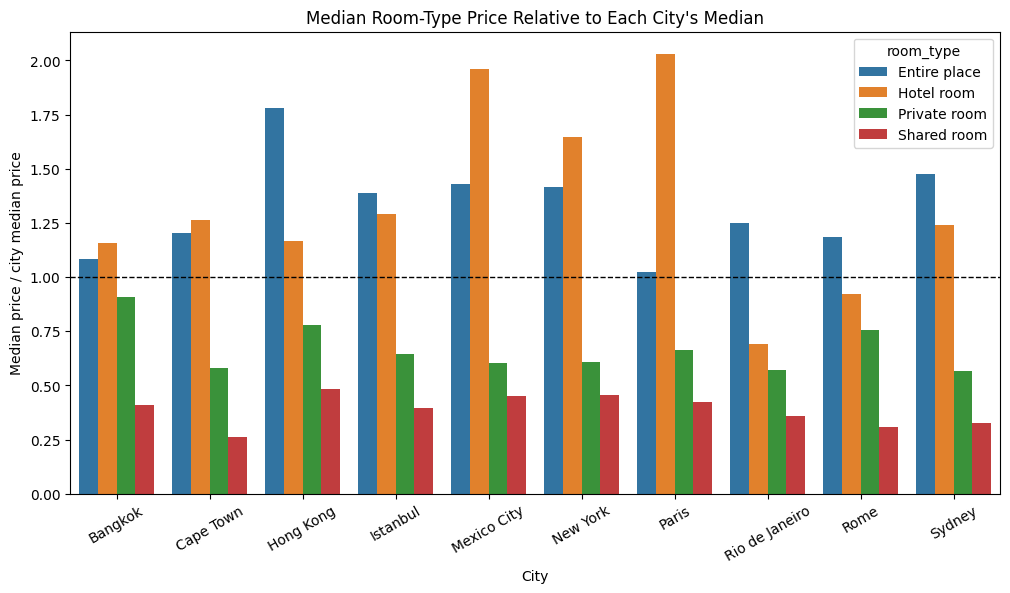

In [64]:
plt.figure(figsize=(12, 6))
sns.barplot(data=room_price, x='city', y='median_price_index', hue='room_type', errorbar=None)
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title("Median Room-Type Price Relative to Each City's Median")
plt.xlabel("City")
plt.ylabel("Median price / city median price")
plt.xticks(rotation=30)
plt.show()

### Findings

- Room types are compared against the median price of their own city, not against raw prices from other currencies.
- Values above 1 indicate a room type that is typically priced above that city's median; values below 1 indicate the opposite.
- This shows whether the room-type price pattern is consistent across markets.

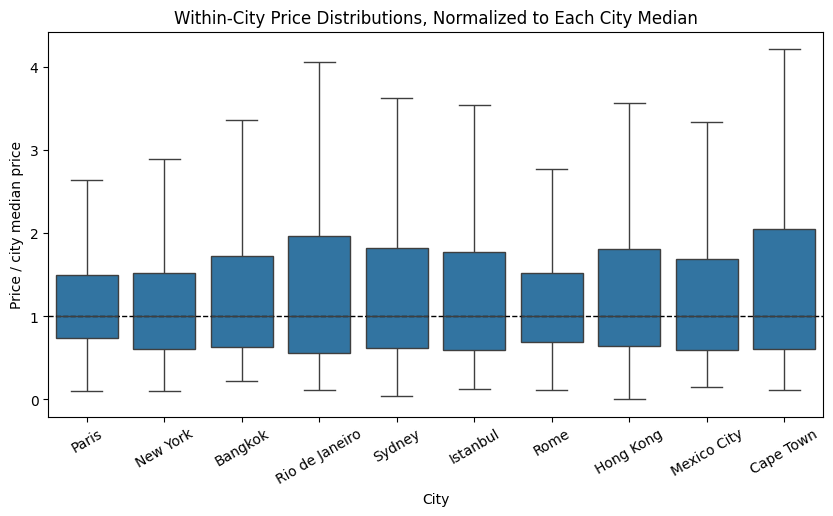

In [65]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='city', y='price_index_city', showfliers=False)
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title("Within-City Price Distributions, Normalized to Each City Median")
plt.xlabel("City")
plt.ylabel("Price / city median price")
plt.xticks(rotation=30)
plt.show()

#### Does accommodating more guests increase listing price?

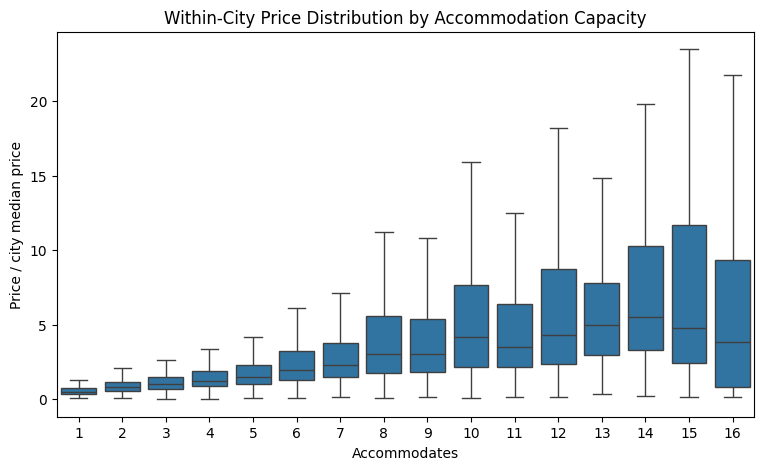

In [66]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="accommodates",
    y="price_index_city",
    showfliers=False
)

plt.title("Within-City Price Distribution by Accommodation Capacity")
plt.xlabel("Accommodates")
plt.ylabel("Price / city median price")

plt.show()

### Findings

- Within cities, listings that accommodate more guests generally have higher median prices.
- Price variability increases as accommodation capacity increases.
- Larger-capacity listings show a wider spread of prices than smaller listings.
- Accommodation capacity appears to be positively associated with within-city price, although other factors also influence pricing.

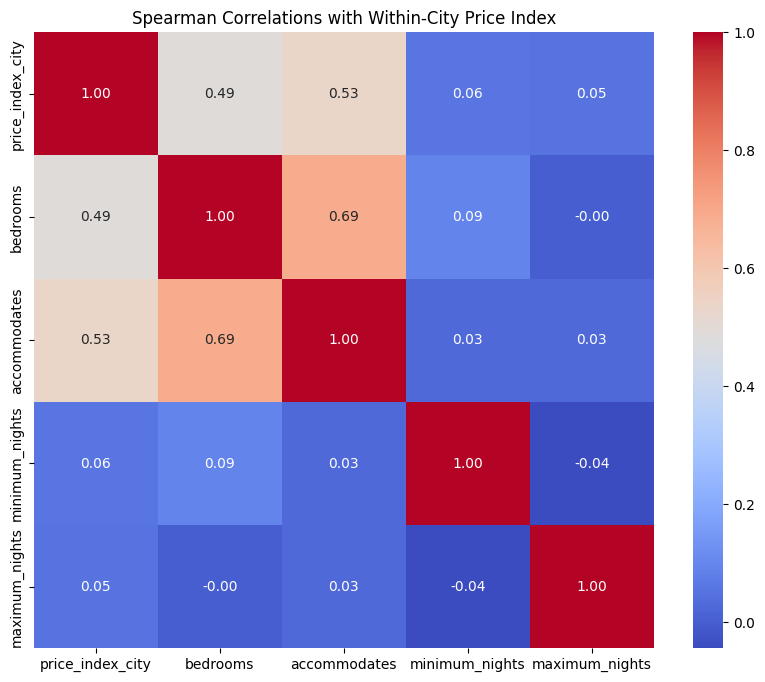

In [67]:
correlation_features = [
    'price_index_city', 'bedrooms', 'accommodates',
    'minimum_nights', 'maximum_nights'
]
correlation_matrix = df[correlation_features].corr(method='spearman')

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Spearman Correlations with Within-City Price Index")

plt.show()

### Findings

- Bedrooms and accommodates have the strongest positive correlation (0.64), indicating that properties with more bedrooms generally accommodate more guests.
- Interpret the price correlations using the within-city price index, which avoids mixing currencies.
- Minimum nights and maximum nights show almost no correlation with price.
- Overall, within-city listing price appears to be influenced by factors beyond the numerical variables included in this analysis.

#### Does amenity availability relate to price?

In [68]:
all_amenities = df['amenities_list'].explode()
amenity_counts = all_amenities.value_counts()
top_amenities = amenity_counts.head(20).index.tolist()

for amenity in top_amenities:
    col = f'has_{amenity.replace(" ", "_").lower()}'
    if col not in df.columns:
        df[col] = df['amenities_list'].apply(lambda x: amenity in x)

amenity_flag_cols = [f'has_{a.replace(" ", "_").lower()}' for a in top_amenities]

amenities_correlation = df[amenity_flag_cols + ['price_index_city']].corr(method='spearman')
display(amenities_correlation[['price_index_city']].sort_values(by='price_index_city', ascending=False))

,price_index_city
price_index_city,1.000000
has_tv,0.239315
has_air_conditioning,0.156115
has_hair_dryer,0.125689
has_washer,0.107069
has_iron,0.105318
has_elevator,0.102017
has_smoke_alarm,0.085471
has_shampoo,0.077223
has_heating,0.065984


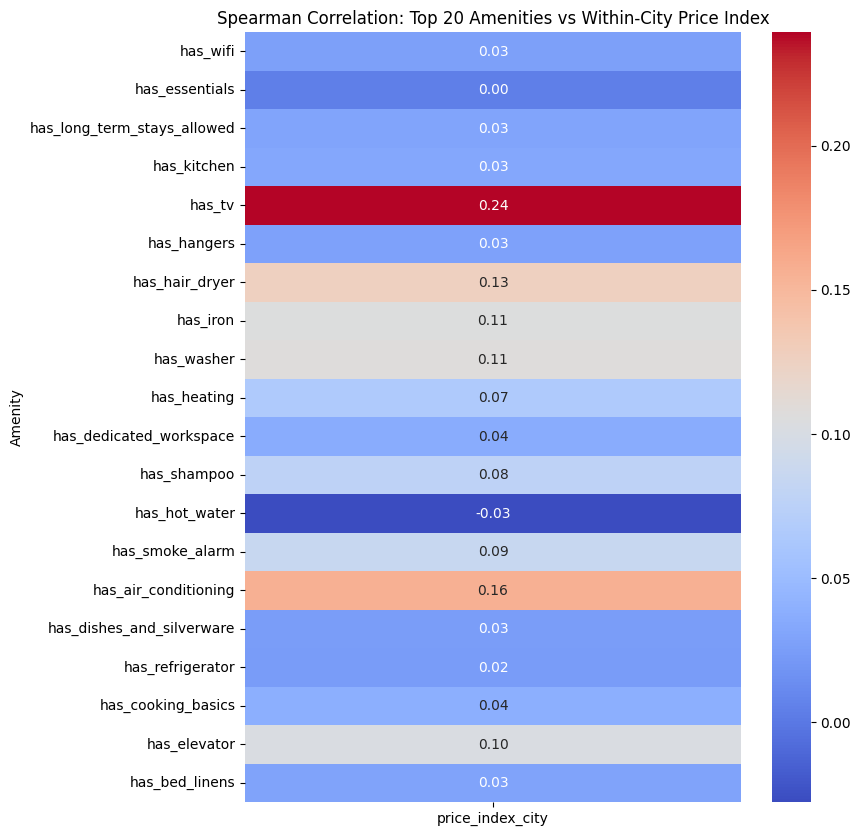

In [69]:
plt.figure(figsize=(8, 10))
sns.heatmap(
    amenities_correlation[['price_index_city']].drop('price_index_city'),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Spearman Correlation: Top 20 Amenities vs Within-City Price Index")
plt.ylabel("Amenity")
plt.show()

In [70]:
print("amenity_count vs price_index_city:",
      df['amenity_count'].corr(df['price_index_city'], method='spearman').round(2))
print("amenity_count vs accommodates:",
      df['amenity_count'].corr(df['accommodates'], method='spearman').round(2))

amenity_count vs price_index_city: 0.15
amenity_count vs accommodates: 0.23


**Findings**

- Individual amenities show only weak correlations with the within-city price index — no single amenity is a strong price driver on its own.
- `amenity_count` correlates weakly-to-moderately with price (Spearman ≈ 0.15) and similarly with `accommodates` (Spearman ≈ 0.23), suggesting larger listings simply tend to offer more amenities, rather than amenity count directly commanding a price premium.

#### Interaction Analyses

In [71]:
# Superhost x Room type x Price
interaction_1 = (
    df.groupby(['room_type', 'host_is_superhost'])['price_index_city']
      .median()
      .round(3)
)
display(interaction_1)

room_type     host_is_superhost
Entire place  False                1.212
              True                 1.231
Hotel room    False                1.303
              True                 1.399
Private room  False                0.657
              True                 0.625
Shared room   False                0.409
              True                 0.354
Name: price_index_city, dtype: float64

In [72]:
# Instant bookable x City
instant_by_city = (
    df.groupby('city')['instant_bookable']
      .apply(lambda x: (x == True).mean() * 100)
      .round(2)
      .sort_values(ascending=False)
)
display(instant_by_city)

,instant_bookable
city,
Bangkok,60.12
Rome,57.95
Istanbul,55.47
Mexico City,51.11
Cape Town,43.10
Sydney,37.55
Hong Kong,34.68
Rio de Janeiro,34.40
Paris,31.93


In [73]:
# Host tenure x Review score (on the reviewed subset only)
df['host_tenure_years'] = (pd.Timestamp('2024-01-01') - df['host_since']).dt.days / 365
df_reviewed_check = df[df['review_scores_rating'].notna()]
print("Host tenure vs review score (Spearman):",
      df_reviewed_check['host_tenure_years'].corr(df_reviewed_check['review_scores_rating'], method='spearman').round(3))

Host tenure vs review score (Spearman): -0.004


**Findings**

- **Superhost × Room type:** Superhosts price slightly above non-Superhosts for Entire place and Hotel room listings, but slightly *below* non-Superhosts for Private and Shared rooms — the Superhost price premium is not uniform across room types.
- **Instant bookable × City:** adoption varies widely, from 60% in Bangkok to 30% in New York, showing this is a market-specific behavior rather than a platform-wide norm.
- **Host tenure × Review score:** essentially no relationship (Spearman ≈ -0.004) — longer-tenured hosts do not receive systematically better or worse reviews.

#### Top Neighbourhoods by Median Price, Within Each City

Neighbourhoods with fewer than 10 listings are excluded from this ranking, since a
single listing can otherwise produce a misleadingly extreme "top" result (e.g. one
listing with a very high price shows up as a 10x city median with no supporting
sample size).

In [74]:
MIN_LISTINGS = 10

top_neighbourhoods_by_city = {}
for city in sorted(df['city'].unique()):
    sub = df[df['city'] == city]
    counts = sub['neighbourhood'].value_counts()
    valid_neighbourhoods = counts[counts >= MIN_LISTINGS].index
    top3 = (
        sub[sub['neighbourhood'].isin(valid_neighbourhoods)]
        .groupby('neighbourhood')['price_index_city']
        .median()
        .sort_values(ascending=False)
        .head(3)
    )
    top_neighbourhoods_by_city[city] = top3

for city, top3 in top_neighbourhoods_by_city.items():
    print(f"\n{city}")
    print(top3.round(3))


Bangkok
neighbourhood
Parthum Wan    1.688
Taling Chan    1.614
Vadhana        1.318
Name: price_index_city, dtype: float64

Cape Town
neighbourhood
Ward 54    2.074
Ward 62    1.871
Ward 74    1.737
Name: price_index_city, dtype: float64

Hong Kong
neighbourhood
Southern      2.575
Islands       2.063
Kwai Tsing    1.606
Name: price_index_city, dtype: float64

Istanbul
neighbourhood
Silivri    2.976
Catalca    2.552
Sile       2.028
Name: price_index_city, dtype: float64

Mexico City
neighbourhood
Miguel Hidalgo           1.399
Cuajimalpa de Morelos    1.355
Cuauhtemoc               1.191
Name: price_index_city, dtype: float64

New York
neighbourhood
Tribeca              2.111
NoHo                 2.071
Flatiron District    1.768
Name: price_index_city, dtype: float64

Paris
neighbourhood
Elysee            1.600
Louvre            1.438
Hotel-de-Ville    1.362
Name: price_index_city, dtype: float64

Rio de Janeiro
neighbourhood
Joa                  8.929
Alto da Boa Vista    2.882
Gar

**Findings**

- After filtering for at least 10 listings, the top neighbourhood in most cities still commands roughly 1.2x to 2.1x the city median price (e.g. Elysee in Paris at 1.6x, Tribeca in New York at 2.1x, I Centro Storico in Rome at 1.2x).
- A few cities show much larger premiums for a single standout neighbourhood — Joa in Rio de Janeiro reaches 8.9x the city median, and Pittwater in Sydney reaches 3.3x — likely reflecting small, exclusive luxury enclaves rather than typical high-demand districts.
- The specific top neighbourhoods differ by city, consistent with each city having its own distinct high-demand districts rather than a single universal pattern. This confirms neighbourhood-level location is a meaningful price driver *within* a city, independent of the cross-city currency issue discussed earlier.

#### Reviewed Listings Subset

In [75]:
df_reviewed = df[df['review_scores_rating'].notna()].copy()
print(f"Reviewed subset size: {len(df_reviewed)} ({len(df_reviewed)/len(df)*100:.1f}% of cleaned data)")

print()
print("Review score vs within-city price index (Spearman):",
      df_reviewed['review_scores_rating'].corr(df_reviewed['price_index_city'], method='spearman').round(3))

print()
print("Median review_scores_rating by Superhost status:")
display(df_reviewed.groupby('host_is_superhost')['review_scores_rating'].median())

Reviewed subset size: 188158 (67.4% of cleaned data)

Review score vs within-city price index (Spearman): 0.083

Median review_scores_rating by Superhost status:


,review_scores_rating
host_is_superhost,
False,95.0
True,98.0


**Findings**

- Restricting review-based analysis to the 67.4% of listings that actually have review scores avoids mixing "genuinely low-rated" listings with "not yet reviewed" listings, which earlier sections showed are missing systematically rather than randomly.
- Within this subset, review score still shows almost no relationship with price (Spearman ≈ 0.08) — reinforcing the earlier finding that guests do not pay a premium for higher-rated listings.
- Superhosts have a higher median review score (98) than non-Superhosts (95), which is expected given Superhost status is partly defined by maintaining high ratings.

In [76]:
# Correlation of every review sub-score with the within-city price index,
# computed only on listings that actually have review data
review_cols = [c for c in df.columns if c.startswith('review_scores')]
review_price_corr = df_reviewed[review_cols + ['price_index_city']].corr()['price_index_city'].sort_values(ascending=False)
display(review_price_corr)

,price_index_city
price_index_city,1.000000
review_scores_location,0.009649
review_scores_cleanliness,0.008595
review_scores_rating,0.005119
review_scores_checkin,-0.004335
review_scores_communication,-0.007076
review_scores_accuracy,-0.007945
review_scores_value,-0.016984


In [77]:
# Superhost vs non-Superhost price, on the reviewed subset only
display(df_reviewed.groupby('host_is_superhost')['price_index_city'].median())

,price_index_city
host_is_superhost,
False,0.960317
True,1.021429


**Findings**

- Every individual review sub-score (rating, accuracy, cleanliness, check-in, communication, location, value) has an essentially negligible correlation with price — all between -0.02 and +0.01. No single review dimension is a meaningful price driver, reinforcing the earlier overall finding at a more granular level.
- Superhosts have a slightly higher median price index (1.02) than non-Superhosts (0.96) on the reviewed subset — a small premium, consistent with the room-type-level pattern found earlier for Entire place and Hotel room listings.

#### Missingness as a Signal

In [78]:
df['has_reviews'] = df['review_scores_rating'].notna()

print("Median price index — with vs without reviews:")
display(df.groupby('has_reviews')['price_index_city'].median())

print()
print("Superhost rate (%) — with vs without reviews:")
display(df.groupby('has_reviews')['host_is_superhost'].apply(lambda x: (x == True).mean() * 100).round(2))

Median price index — with vs without reviews:


,price_index_city
has_reviews,
False,1.076923
True,0.987500



Superhost rate (%) — with vs without reviews:


,host_is_superhost
has_reviews,
False,5.25
True,24.17


**Findings**

- Listings without any reviews have a nearly identical median price index (1.08) to reviewed listings (0.99) — missing reviews are not associated with distinctly under- or over-priced listings.
- Superhost rate is dramatically different: only 5.2% of listings without reviews belong to Superhosts, versus 24.2% of reviewed listings. This confirms that the missingness in review scores is systematically tied to newer/less-established hosts, not random — supporting the earlier decision to keep these values as NaN rather than impute them.

#### Multi-Listing Hosts vs Solo Hosts

In [79]:
host_listing_counts = df['host_id'].value_counts()
df['is_multi_listing_host'] = df['host_id'].map(host_listing_counts) > 1

print(df['is_multi_listing_host'].value_counts())
print()
print("Median price index — solo vs multi-listing hosts:")
display(df.groupby('is_multi_listing_host')['price_index_city'].median())

print()
print("Superhost rate (%) — solo vs multi-listing hosts:")
display(df.groupby('is_multi_listing_host')['host_is_superhost'].apply(lambda x: (x == True).mean() * 100).round(2))

print()
print("Median review score (reviewed subset only) — solo vs multi-listing hosts:")
df_reviewed['is_multi_listing_host'] = df_reviewed['host_id'].map(host_listing_counts) > 1
display(df_reviewed.groupby('is_multi_listing_host')['review_scores_rating'].median())

is_multi_listing_host
False    149816
True     129443
Name: count, dtype: int64

Median price index — solo vs multi-listing hosts:


,price_index_city
is_multi_listing_host,
False,1.000000
True,1.010101



Superhost rate (%) — solo vs multi-listing hosts:


,host_is_superhost
is_multi_listing_host,
False,12.87
True,23.93



Median review score (reviewed subset only) — solo vs multi-listing hosts:


,review_scores_rating
is_multi_listing_host,
False,97.0
True,96.0


**Findings**

- Solo hosts (149,816 listings) and multi-listing hosts (129,443 listings) are split roughly evenly in this dataset.
- Median price index is nearly identical between the two groups (1.00 vs 1.01) — managing multiple listings is not associated with charging more.
- Multi-listing hosts are almost twice as likely to hold Superhost status (23.9% vs 12.9%) — likely because experience and volume help hosts meet Superhost consistency requirements.
- Median review score is essentially the same for both groups (96 vs 97), so guest satisfaction does not meaningfully differ between solo and multi-listing hosts.

#### Response Time Category vs Response Rate

In [80]:
response_order = ['within an hour', 'within a few hours', 'within a day', 'a few days or more']
df['host_response_time_ordered'] = pd.Categorical(
    df['host_response_time'], categories=response_order, ordered=True
)

print("Mean host_response_rate by response-time category (ordered fastest to slowest):")
display(df.groupby('host_response_time_ordered', observed=True)['host_response_rate'].mean().round(3))

print()
print("Median host_response_rate by response-time category:")
display(df.groupby('host_response_time_ordered', observed=True)['host_response_rate'].median().round(3))

Mean host_response_rate by response-time category (ordered fastest to slowest):


,host_response_rate
host_response_time_ordered,
within an hour,0.983
within a few hours,0.954
within a day,0.839
a few days or more,0.092



Median host_response_rate by response-time category:


,host_response_rate
host_response_time_ordered,
within an hour,1.00
within a few hours,1.00
within a day,0.97
a few days or more,0.00


**Findings**

- The two metrics are highly consistent with each other: mean response rate drops steadily from 98.3% ("within an hour") to 95.4% ("within a few hours") to 83.9% ("within a day"), then collapses to 9.2% for "a few days or more".
- This confirms `host_response_time` and `host_response_rate` capture the same underlying host-responsiveness behavior from two angles, and the sharp drop for the slowest category suggests these hosts rarely respond at all rather than simply responding slowly.

In [89]:
cluster_features = [
    'log_price_relative_city',
    'price_per_guest_index',
    'accommodates',
    'bedrooms',
    'minimum_nights',
    'amenity_count',
    'host_tenure_years',
    'has_reviews',
    'is_multi_listing_host'
]

cluster_df = df[cluster_features].copy()

# Encode booleans as 0/1
cluster_df['has_reviews'] = cluster_df['has_reviews'].astype(int)
cluster_df['is_multi_listing_host'] = cluster_df['is_multi_listing_host'].astype(int)

# minimum_nights is heavily right-skewed, same treatment style as log_price_relative_city
cluster_df['minimum_nights'] = np.log1p(cluster_df['minimum_nights'])

print(cluster_df.isna().sum())
cluster_df.describe().round(2)

log_price_relative_city    0
price_per_guest_index      0
accommodates               0
bedrooms                   0
minimum_nights             0
amenity_count              0
host_tenure_years          0
has_reviews                0
is_multi_listing_host      0
dtype: int64


,log_price_relative_city,price_per_guest_index,accommodates,bedrooms,minimum_nights,amenity_count,host_tenure_years,has_reviews,is_multi_listing_host
count,279259.00,279259.00,279259.00,279259.00,279259.00,279259.00,279259.00,279259.00,279259.00
mean,0.09,0.58,3.29,1.46,1.49,19.56,7.73,0.67,0.46
std,0.80,2.80,2.13,1.10,0.96,9.24,2.44,0.47,0.50
min,-5.96,0.00,1.00,1.00,0.69,0.00,2.85,0.00,0.00
25%,-0.45,0.25,2.00,1.00,0.69,13.00,5.73,0.00,0.00
50%,0.00,0.38,2.00,1.00,1.10,18.00,7.88,1.00,0.00
75%,0.51,0.56,4.00,2.00,1.79,26.00,9.51,1.00,1.00
max,7.71,446.58,16.00,50.00,9.21,89.00,15.40,1.00,1.00


In [90]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

In [91]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km_labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f'k={k} | inertia={km.inertia_:,.0f} | silhouette={sil:.3f}')

k=2 | inertia=2,152,791 | silhouette=0.231
k=3 | inertia=1,893,558 | silhouette=0.193
k=4 | inertia=1,724,121 | silhouette=0.179
k=5 | inertia=1,561,944 | silhouette=0.182
k=6 | inertia=1,426,961 | silhouette=0.191
k=7 | inertia=1,356,819 | silhouette=0.204
k=8 | inertia=1,291,019 | silhouette=0.197


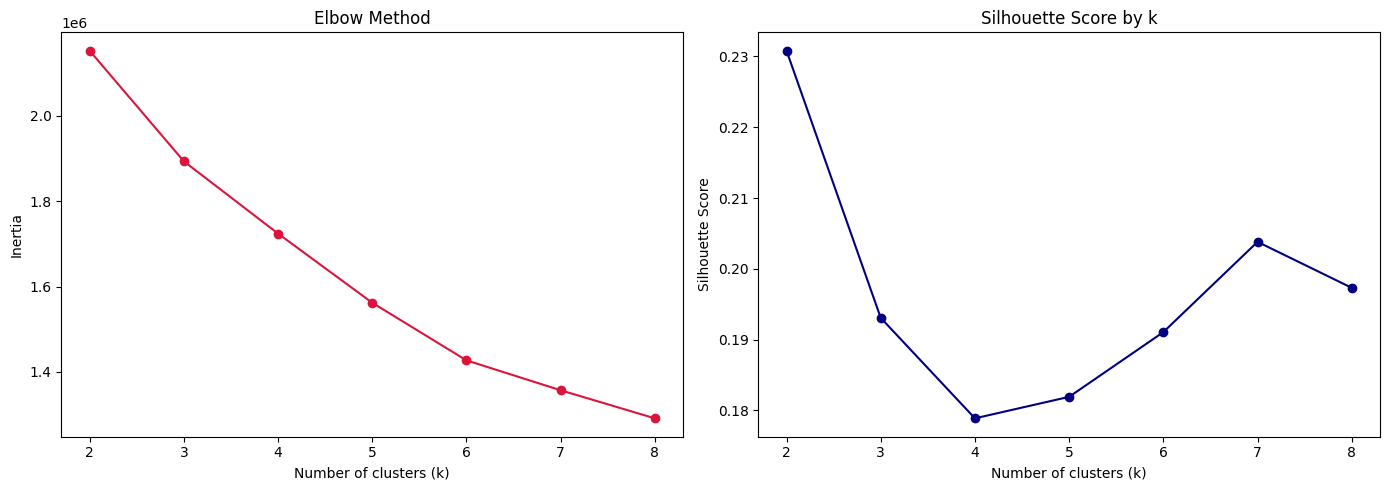

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='crimson')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='navy')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [93]:
k_optimal = 4
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster_kmeans'], sample_size=5000, random_state=42)
print(f'Silhouette Score (k={k_optimal}): {sil_final:.3f}')
df['cluster_kmeans'].value_counts().sort_index()

Silhouette Score (k=4): 0.179


,count
cluster_kmeans,
0,90249
1,32108
2,77349
3,79553


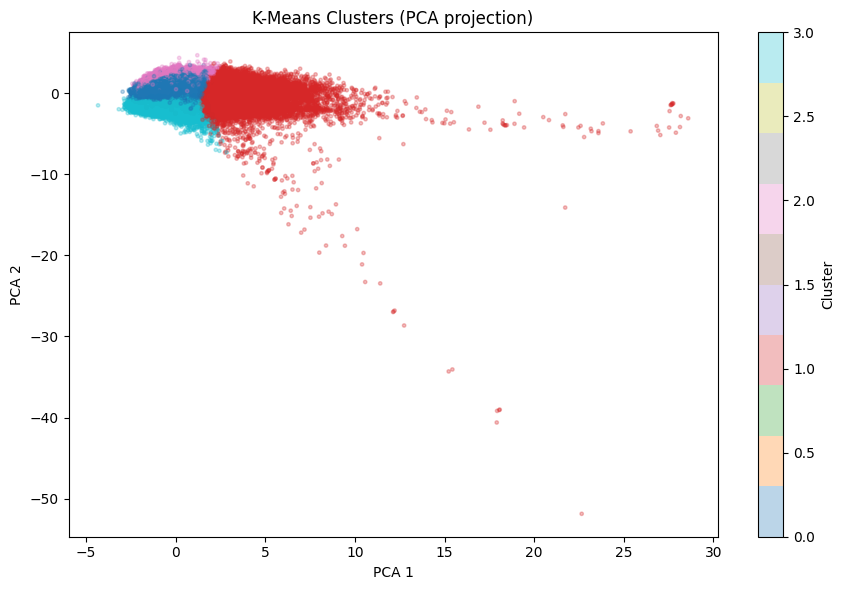

Variance explained by 2 PCA components: 39.0%


In [94]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'],
                       cmap='tab10', alpha=0.3, s=6)
plt.title('K-Means Clusters (PCA projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

print(f'Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum():.1%}')

In [95]:
cluster_profile = df.groupby('cluster_kmeans')[cluster_features].mean().round(2)
cluster_profile['n_listings'] = df['cluster_kmeans'].value_counts().sort_index()
cluster_profile

,log_price_relative_city,price_per_guest_index,accommodates,bedrooms,minimum_nights,amenity_count,host_tenure_years,has_reviews,is_multi_listing_host,n_listings
cluster_kmeans,,,,,,,,,,
0,-0.08,0.43,2.79,1.23,8.12,19.80,8.16,1.00,0.00,90249
1,1.26,1.25,7.45,3.35,6.81,24.82,7.91,0.67,0.53,32108
2,-0.13,0.42,2.85,1.20,6.32,22.22,7.80,0.99,1.00,77349
3,0.02,0.63,2.60,1.23,10.15,14.60,7.09,0.00,0.44,79553


In [96]:
pd.crosstab(df['cluster_kmeans'], df['room_type'], normalize='index').round(2) * 100

room_type,Entire place,Hotel room,Private room,Shared room
cluster_kmeans,,,,
0,76.0,0.0,23.0,1.0
1,93.0,1.0,6.0,1.0
2,57.0,4.0,37.0,2.0
3,50.0,2.0,44.0,3.0


In [98]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=1500, replace=False)
X_sample = X_scaled[sample_idx]

In [99]:
X_sample.shape

(1500, 9)

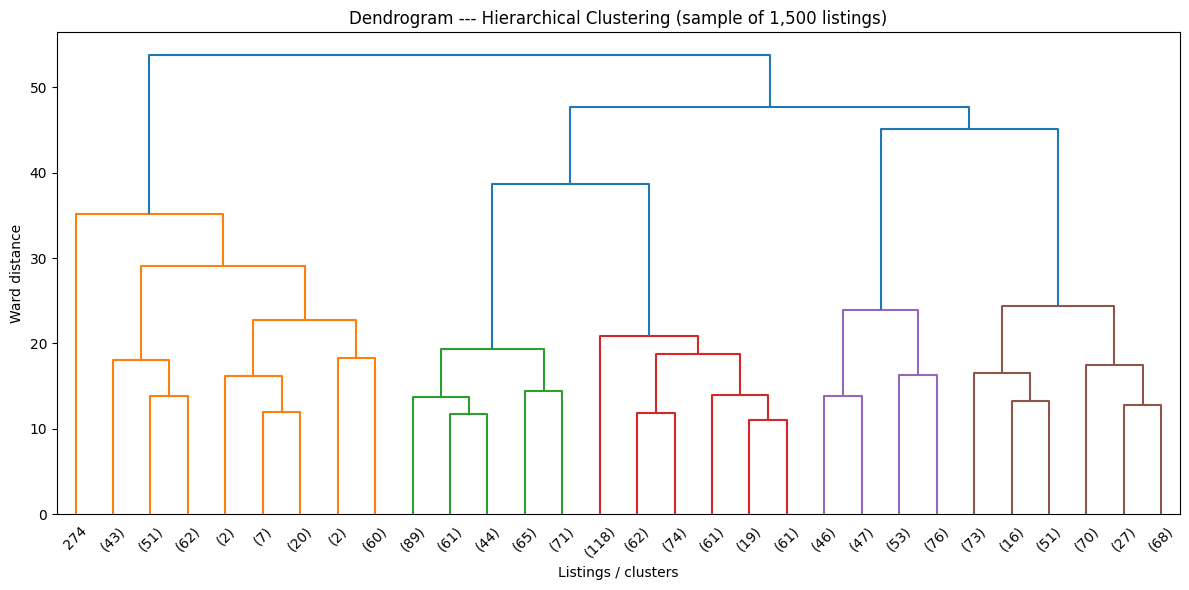

In [100]:
linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Dendrogram --- Hierarchical Clustering (sample of 1,500 listings)')
plt.xlabel('Listings / clusters')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.show()

In [101]:
agg_clustering = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
hier_labels = agg_clustering.fit_predict(X_sample)

sil_hier = silhouette_score(X_sample, hier_labels)
print(f'Silhouette Score (Hierarchical, k={k_optimal}): {sil_hier:.3f}')
pd.Series(hier_labels).value_counts().sort_index()

Silhouette Score (Hierarchical, k=4): 0.174


,count
0,725
1,248
2,305
3,222


In [102]:
kmeans_labels_sample = df['cluster_kmeans'].values[sample_idx]

comparison = pd.crosstab(kmeans_labels_sample, hier_labels,
                          rownames=['K-Means'], colnames=['Hierarchical'])
comparison

Hierarchical,0,1,2,3
K-Means,,,,
0,385,6,0,72
1,13,147,17,3
2,327,58,2,53
3,0,37,286,94


In [103]:
ari = adjusted_rand_score(kmeans_labels_sample, hier_labels)
print(f'Adjusted Rand Index (K-Means vs Hierarchical): {ari:.3f}')

print('\nSilhouette Score summary:')
print(f'  K-Means (full dataset)        : {sil_final:.3f}')
print(f'  Hierarchical (1,500 sample)   : {sil_hier:.3f}')

Adjusted Rand Index (K-Means vs Hierarchical): 0.383

Silhouette Score summary:
  K-Means (full dataset)        : 0.179
  Hierarchical (1,500 sample)   : 0.174


Clustering Summary

Unsupervised clustering on the engineered listing/host features
(rather than raw `price`) reveals four consistent market segments:
single-listing established hosts, professional multi-listing hosts,
large/luxury properties, and newer listings without review history yet.
This segmentation could feed directly into the "Feature Engineering /
Modeling" stage outlined in Section 11 --- for example, `cluster_kmeans`
could be used as a categorical feature, or `has_reviews`/
`is_multi_listing_host` could define separate modeling subsets to avoid
mixing established and brand-new listings in the same price model.

### 8. Key Insights

1. Because prices use different local currencies, raw price averages and medians must not be reported across the full dataset. Within-city price comparisons use the price index (price divided by the city median).
2. Most listings are designed for small groups: median accommodates = 2, even though the mean (3.29) suggests otherwise — the platform primarily serves couples/solo travelers.
3. Entire-place listings dominate (65.1%), showing that the platform is primarily composed of whole-property rentals; host business model cannot be inferred from this measure alone.
4. Hotel rooms and shared rooms combined represent under 4% of listings, indicating this platform leans heavily toward private, non-hotel-style stays.
5. The extreme skew initially found in maximum_nights (283.99) was driven by just 3 records containing a system placeholder value (2,147,483,647) rather than real data — a reminder that a single extreme value can completely distort summary statistics in a large dataset.
6. Superhosts represent only 17.99% of hosts, showing that Superhost status is a meaningful differentiator rather than a common default.
7. Instant booking is used by 41.37% of listings — common, but not yet the majority — suggesting room for platform-level growth in this feature.
8. Raw city median prices are not ranked because they are reported in different currencies. Any future USD comparison must use documented historical exchange rates from the dataset collection period.
9. Room-type price differences are evaluated relative to each city's median, showing how accommodation type is positioned within each market.
10. Bedrooms and accommodation capacity should be interpreted against the within-city price index, so associations are not distorted by currency differences.
11. Missingness in review scores and host response metrics is systematic (~32-46% missing together), corresponding to listings with no booking/review history yet, not random data entry errors.

### 9. Business Recommendations

1. Keep price analysis within each city unless historical exchange rates from the data-collection period are documented. The notebook now uses a within-city price index for comparisons across markets.
2. Add validation rules at data entry to block system placeholder values (e.g., int32-max) from being stored as real user-facing values like maximum_nights — this prevents statistical distortion in any future analysis relying on this field.
3. Encourage new hosts to complete their response history and accept their first bookings quickly, since ~34-46% of host-related fields are missing together, likely corresponding to inactive/new hosts who may be under-visible to guests.
4. Promote instant booking adoption further, since currently only 41.37% of listings use it, despite being linked to smoother guest experience.
5. Simplify the property_type taxonomy (144 raw categories) into a smaller standardized set at the point of listing creation, both to improve data quality and make search/filtering easier for guests.

### 10. Reflection

1. **Most challenging data quality problem:** identifying that the extreme skew in `maximum_nights` was caused by a hidden system placeholder value (2,147,483,647) rather than genuine data — this required cross-checking summary statistics against raw value distributions rather than trusting `.describe()` output at face value.
2. **Decision requiring the most critical thinking:** avoiding raw cross-city price comparisons because values are recorded in local currencies. The final analysis uses prices relative to each city's median unless historical exchange rates are available.
3. **Most interesting finding:** review scores show almost no correlation with price, suggesting guests don't pay a premium for quality on this platform — counter to initial intuition.
4. **What I'd do differently:** check for sentinel/placeholder values systematically across all numerical columns earlier in the process, since a single extreme value can silently distort skewness and mean calculations.
5. **What I learned about EDA:** summary statistics like mean and skew can be misleading without inspecting the underlying raw values — real EDA requires verifying *why* a number looks the way it does, not just reporting it.

### 11. Summary, Limitations & Preparation for Feature Engineering

**Engineered features created in this notebook**

| Feature | Description |
|---|---|
| `price_index_city` | Price relative to each city's own median (currency-safe) |
| `log_price_relative_city` | Log of the above, for symmetric distribution analysis |
| `price_per_guest_index` | `price_index_city` divided by `accommodates` |
| `amenity_count` | Total number of amenities parsed from `amenities` |
| `has_wifi`, `has_pool`, `has_kitchen` | Boolean flags for specific high-relevance amenities |
| `property_type_grouped` | 144 raw categories simplified into 5 broad groups |
| `host_tenure_years` | Years since the host joined Airbnb |
| `has_reviews` | Boolean flag marking whether a listing has any review data |

**Key limitations**

- Exact currency conversion rates for the data-collection period are unavailable, so all cross-city price comparisons in this notebook rely on within-city relative pricing (`price_index_city`) rather than a single absolute currency.
- Review scores are missing systematically (not at random) for newer or less-established listings, so any model using review-related features should account for this rather than imputing blindly.
- `amenities` is free-text-derived; amenity naming is not fully standardized (e.g. "Wifi" vs "Pocket wifi"), so amenity-level features should be treated as approximate.

**Recommendations for the next stage (Feature Engineering / Modeling)**

- Use `price_index_city` (or a properly currency-converted price, if exchange rates become available) as the modeling target rather than raw `price`.
- Treat `city` and `property_type_grouped` as categorical features; `neighbourhood` is high-cardinality and likely needs target encoding rather than one-hot encoding.
- Consider `has_reviews` as an explicit model feature (or a two-stage model) rather than dropping or imputing the ~33% of listings without review data.
- Aggregate host-level features (e.g. `host_total_listings_count`) carefully to avoid data leakage between multiple listings owned by the same professional host.